In [ ]:
import scipy
import numpy as np
from numba import jit
import matplotlib.pyplot as plt

import time
import random
import copy
import stan

# Set hyperparameters

In [ ]:
# Hyperparameters
# Random
seed = 1234
random.seed(seed)
np.random.seed(seed) 

# Set up args
args = dict()

args['sim_num'] = 10 # Sim round
args['M'] = 1000 # Number of machines
args['N'] = 10 # Number of site
args['K'] = 80 # Maximum of period that we allow machine to operate before replacement
args['r_limit'] = 10 # Limit of l_k value before replacement
args['s_limit'] = 11 # Limit of l_k value that will be consolidated into 1 state
args['S'] = 20 # Number of discrete state space
args['gamma'] = 0.99 # discounting factor
args['max_iter'] = 1000 # Maximum number of iteration for value iteration
args['c1'] = -20 # Cost of urgent replacement
args['c2'] = -5 # Cost of preventive replacement
args['c3'] = -0.05 # Cost of maintenance
args['delta'] = 1 # Lag time between t_k and t_k-1 # note that this is assumed to be always constant
args['theta'] = 0 # l_0
args['mu3'] = 5 # Value of the true parameter for beta
args['sigma1'] = 0.01 # Fixed sigma for beta
args['sigma2'] = 0.1
args['sigma3'] = 5
args['sigma'] = 0.1 # Fixed sigma for brownian motion
args['mu_true'] = 0.8 # True mu for mu3

In [ ]:
def sample_transition(beta, args):
    epsilon = np.random.randn(args['K']+1) * args['sigma']
    epsilon[0] = 0

    tk_list = np.arange(args['K']) * args['delta']
    lk_list = args['theta'] + beta * tk_list + np.cumsum(epsilon)[:-1]
    return lk_list

def discretize_states(lk_list, args):
    bins = np.linspace(args['theta'], args['s_limit'], args['S']-1)
    discrete_state_space = np.digitize(lk_list, bins, right=False)
    return discrete_state_space, bins

def calc_one_step_transition_prob(mean, std, lk, bins, delta, sigma):
    # Calculate mean and std for l_{k+1}
    mean_lk1 = lk + mean * delta
    std_lk1 = np.sqrt(std**2 * delta**2 + sigma**2)

    # Derive cdf of max of each bin
    normalized_bins = (bins - mean_lk1) / std_lk1
    cdf_bins = scipy.stats.norm.cdf(normalized_bins)
    
    prob = np.diff(cdf_bins)
    prob = np.insert(prob, 0, cdf_bins[0]) # Add prob for lk <= 0
    prob = np.append(prob, 1 - cdf_bins[-1])
    return prob

def calc_transition_prob(state_partition, bins, prior_mean, prior_std, args):
    # Matrix of K x S x Sw
    prob = np.zeros((args['K'], args['S'], args['S']))
    for k in range(args['K']):
        for s in range(args['S']):
            tk = args['delta'] * k
            lk = state_partition[s]
            # Update posterior distribution by approximated lk if k > 0
            if k > 0:
                a = ((tk**2) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)) + (1/(prior_std**2))
                b = (((lk - args['theta']) * tk) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)) + (prior_mean/(prior_std**2))

                mu_k = b/a
                sigma_k = np.sqrt(1/a)

            else:
                mu_k = prior_mean
                sigma_k = prior_std
        
            prob[k, s, :] = calc_one_step_transition_prob(mu_k, sigma_k, lk, bins, args['delta'], args['sigma'])
    
    return prob

def value_iteration(mean, std, bins, args, threshold=0.1):  
    converge = 0
    
    c1 = args['c1']
    c2 = args['c2']
    c3 = args['c3']

    gamma = args['gamma']
    sigma = args['sigma']
    sigma1 = args['sigma1']
    theta = args['theta']
    
    value = np.zeros((args['K'], args['S']))
    pi = np.zeros((args['K'], args['S']))

    new_bins = copy.deepcopy(bins)
    new_bins[1:] = bins[1:] - np.diff(bins)[0] / 2
    new_bins = np.append(new_bins, args['s_limit'])

    # Pre calculate transition probability to avoid repetition when doing value iteration 
    prob = calc_transition_prob(new_bins, bins, mean, std, args)

    for i in range(args['max_iter']):
        old_value = copy.deepcopy(value)
        for k in range(args['K']-1):
            for s in range(args['S']):
                # At state (k, s)
                # Check edge case
                lk = new_bins[s]
                if lk > args['r_limit']:
                    value[k, s] = c1 + gamma * value[0, 0]
                    pi[k, s] = 1
                    continue

                if k == args['K'] - 1:
                    value[k, s] = c3 if lk <= args['r_limit'] else c1
                    pi[k, s] = 0 if lk <= args['r_limit'] else 1
                    continue

                # Two possible actions: replace and not replace
                # Calculate transition probability
                curr_prob = prob[k, s]
                future_cost = gamma * value[k+1, :]

                # Evaluate value of current state
                cost_A0 = np.sum(np.multiply(curr_prob, c3 + future_cost)) # Not replacing machine
                cost_A1 = c2 + gamma * value[0, 0] # Replacing machine
                
                value[k, s] = max(cost_A0, cost_A1)
                pi[k, s] = int(cost_A0 < cost_A1)
        # if i % 5 == 0:
        #     print(f"Iter {i+1}: diff value = {np.linalg.norm(old_value - value)}")
        if np.linalg.norm(old_value - value) < threshold:
            converge = 1
            break 
    if converge == 0:
        print("Reach maximum iteration before convergent")

    return value, pi

def calc_cost(pi, lk_list, discrete_lk_list, args):
    for k in range(args["K"]):
        if pi[k, int(discrete_lk_list[k])] > 0.5:
            if lk_list[k] > args["r_limit"]:
                if args["gamma"] == 1:
                    cost = k * args["c3"] + args["c1"]
                else:
                    cost = args["c3"]*(1-args["gamma"]**(k+1))/(1-args["gamma"]) + args["c1"]*args["gamma"]**k
            else:
                if args["gamma"] == 1:
                    cost = k * args["c3"] + args["c2"]
                else: 
                    cost = args["c3"]*(1-args["gamma"]**(k+1))/(1-args["gamma"]) + args["c2"]*args["gamma"]**k
            return k, lk_list[k], cost
        
    if args["gamma"] == 1:
        cost = k * args["c3"] + args["c1"]
    else: 
        cost = args["c3"]*(1-args["gamma"]**(k+1))/(1-args["gamma"]) + args["c1"]*args["gamma"]**k
    return k, lk_list[k], cost

In [ ]:
def update_posterior(lk_list, args):
    A = np.zeros((args['N']+1, args['N']+1))
    B = np.zeros((args['N']+1, 1))

    B[0, 0] = args['mu3'] / args['sigma3']**2
    A[0, 0] = (args['N']/args['sigma2']**2) + (1/args['sigma3']**2)

    for i in range(args['N']):
        A[0, i+1] = -1/args['sigma2']**2
        A[i+1, 0] = -1/args['sigma2']**2
        A[i+1, i+1] = 1/args['sigma2']**2

        for (k, lk) in lk_list[i]:
            tk = k * args['delta']
            A[i+1, i+1] += (tk**2) / (k*args['sigma']**2 + tk**2*args['sigma1']**2)
            B[i+1, 0] += ((lk - args['theta'])*tk) / (k*args['sigma']**2 + tk**2*args['sigma1']**2)

    if np.linalg.matrix_rank(A) == args['N']+1:
        posterior_mu0_mean = np.linalg.solve(A, B).flatten()
    else:
        posterior_mu0_mean = np.linalg.lstsq(A, B, rcond=None)[0].flatten()
    posterior_mu0_cov = np.linalg.inv(A)
    posterior_mu0_std = np.sqrt(np.diag(posterior_mu0_cov))
    
    return posterior_mu0_mean, posterior_mu0_cov, posterior_mu0_std 
    
def update_isolated_posterior(lk_list, args):
    posterior_mu0_mean = np.zeros(args['N']+1)
    posterior_mu0_std = np.ones(args['N']+1)
    
    sigma2 = args['sigma2']
    sigma3 = args['sigma3']

    for n in range(args['N']):
        a = 1 / (sigma2**2 + sigma3**2)
        b = args['mu3'] / (sigma2**2 + sigma3**2)
        for (k, lk) in lk_list[n]:
            tk = k*args['delta']
            a += (tk**2) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)
            b += (tk*(lk - args['theta'])) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)

        posterior_mu0_mean[n+1] = b / a
        posterior_mu0_std[n+1] = np.sqrt(1 / a)

    return posterior_mu0_mean, posterior_mu0_std
    
def update_EP_posterior(r_list, Q_list, r0, Q0, lk_list, args):
    # Device-side
    r_delta = 0
    Q_delta = 0

    r_list_new = []
    Q_list_new = []

    for i in range(args['N']):
        # Subtract old r from r0 and old Q from Q0 to remove the impact of old params
        r_cavity = r0 - r_list[i] 
        Q_cavity= Q0 - Q_list[i]

        # Initialize linear shift and precision mat of tilted dist.
        r_hybrid = r_cavity; Q_hybrid = Q_cavity
        
        # Compute f_k(mu_2)
        for k, lk in lk_list[i]:
            tk = args['delta'] * k
            denom = k * args['sigma'] ** 2 + tk**2 * (args['sigma1']**2 + args['sigma2']**2)
            r_hybrid += (tk*(lk-args['theta'])) / denom
            Q_hybrid += (tk**2) / denom
        
        # Update the contribution to the central prior
        r_delta += r_hybrid - r0
        Q_delta += Q_hybrid - Q0

#         print(f"Site {i} | approx r = {r_list[i]} | true r = {r_hybrid - r_cavity} | approx Q = {Q_list[i]} | true Q = {Q_hybrid - Q_cavity}")

        # Append new r_list and Q_list (local approximation)
        r_list_new.append(r_hybrid - r_cavity)
        Q_list_new.append(Q_hybrid - Q_cavity)

    # Update global approximation
    r0_new = r0 + r_delta
    Q0_new = Q0 + Q_delta

    return r0_new, Q0_new, r_list_new, Q_list_new

def device_posterior_update(r0, Q0, r_list, Q_list, lk_list, args):
    mu0_list = [0]
    sigma0_list = [1]
    for i in range(args['N']):
        # (Implicitly) calc mean and variance of q_sub_i(mu_2)
        r_sub_i = r0 - r_list[i]
        Q_sub_i = Q0 - Q_list[i]
        
        tk_sum = 0
        lk_sum = 0
        for k, lk in lk_list[i]:
            tk = args['delta'] * k
            denom = k * args['sigma']**2 + tk**2 * args['sigma1']**2
            
            tk_sum += tk**2 / denom
            lk_sum += (lk - args['theta']) * tk / denom 

        # Calc mu and Sigma
        A = (1 / (args['sigma2']**2 + (1 / Q_sub_i))) + tk_sum
        B = (r_sub_i / (Q_sub_i * args['sigma2']**2 + 1)) + lk_sum
#         with np.printoptions(precision=3, suppress=True):
#             print(f"Site {i} | A = {A:.3f} | B= {B:.3f} | tk = {tk_sum:.3f} | lk = {lk_sum:.3f} | r = {r_sub_i:.3f} | Q = {Q_sub_i:.3f}")
        sigma_new = np.sqrt(1 / A)
        mu_new = B / A

        mu0_list.append(mu_new)
        sigma0_list.append(sigma_new)

    return mu0_list, sigma0_list

In [ ]:
def run_sim(args, r, experiment="federated"):
    print(f'Simulation round {r+1}: running {experiment} experiment...')
    # Set placeholder for history
    hist_lk_list = [[] for n in range(args['N'])]
    hist_cost_list = [[] for n in range(args['N'])]
    
    random.seed(1234)
    np.random.seed(1234)

    mu1_list = np.random.randn(args['N']) * args['sigma2'] + args['mu_true'] # Sample mu1's
    
    # Prior for (mu2, mu1_list)
    B0 = np.zeros((args['N']+1, 1))
    B0[0, 0] = args['mu3'] / args['sigma3']**2
    
    A0 = np.zeros((args['N']+1, args['N']+1))
    A0[0, 0] = args['N'] / args['sigma2']**2 + 1 / args['sigma3']**2
    
    for i in range(args['N']):
        A0[0, i+1] = -1 / args['sigma2']**2
        A0[i+1, 0] = -1 / args['sigma2']**2
        A0[i+1, i+1] = 1 / args['sigma2']**2

    # Calculate prior for mean and covariance
    mu0_mean = np.linalg.solve(A0, B0).flatten()        
    mu0_cov = np.linalg.inv(A0)
    mu0_std = np.sqrt(np.diag(mu0_cov))

    if experiment == 'federated_EP':
        Q_list = 1 / np.diag(mu0_cov[1:, 1:])
        r_list = np.multiply(Q_list,  mu0_mean[1:])

        r0 = args['mu3'] / args['sigma3']**2
        Q0 = 1 / args['sigma3']**2

        r0 += np.sum(r_list)
        Q0 += np.sum(Q_list)
        
    print(f"True mu are {[args['mu_true']] + list(mu1_list)}")
    mu0_mean_mat = np.zeros((args['N'], args['M']))
    mu0_std_mat = np.zeros((args['N'], args['M']))
    # Simulate
    for i in range(args['M']):
        print(f"--------Machine: {i+1}---------")
        # mu is vector of (mu2, mu1^(1), mu1^(2), ..., mu1^(N)) in R^{N+1}
        
        print(f"Prior for mean of vector mu is {mu0_mean}")
        print(f"Prior for std of vector mu is {mu0_std}")
        if experiment == 'federated_EP':
            print("***************")
            print(f"Prior for r is {r_list}")
            print(f"Prior for Q is {Q_list}")
            print("***************")
        
        for n in range(args['N']):
            # print(f"********Site {n+1}*********")
            mu1_mean = args['mu3'] if experiment == "OVI" else mu0_mean[n+1] # prior mean of mu1
            mu1_std = np.sqrt(args['sigma1']**2 + args['sigma2']**2 + args['sigma3']) if experiment == "OVI" else np.sqrt(mu0_std[n+1]**2 + args['sigma']**2) # prior std of mu1
            mu1 = mu1_list[n] # true mu1
            
            # Simulate beta true
            beta_true = np.random.randn(1) * args['sigma1'] + mu1
            
            # Simulate transitions
            lk_list = sample_transition(beta_true, args)
            discrete_lk_list, bins = discretize_states(lk_list, args)
    
            # Derive optimal policy pi
            if i % 100 == 0:
                # print(mu1_mean, mu1_std)
                value, pi = value_iteration(mu1_mean, mu1_std, bins, args)
                # print("Finish value iteration")

            # plt.matshow(np.flip(np.transpose(pi), axis=0))
            # plt.show()

            # ------------------ Calculate cost ------------------------------------
            k, lk, cost = calc_cost(pi, lk_list, discrete_lk_list, args)
            hist_lk_list[n].append((k, lk))
            hist_cost_list[n].append(cost)
#             print("Device %s, k: %s, lk: %.4f, cost: %.4f"%(n,k,lk,cost))

        # Update posterior
        if experiment == "federated":
            mu0_mean, _, mu0_std = update_posterior(hist_lk_list, args)
        elif experiment == "isolated":
            mu0_mean, mu0_std = update_isolated_posterior(hist_lk_list, args)
        elif experiment == 'federated_EP':
            r0, Q0, r_list_new, Q_list_new = update_EP_posterior(r_list, Q_list, r0, Q0, hist_lk_list, args)
            mu0_mean, mu0_std = device_posterior_update(r0, Q0, r_list_new, Q_list_new, hist_lk_list,args)

            # Update r_list and Q_list
            r_list_old = r_list; Q_list_old = Q_list
            r_list = r_list_new; Q_list = Q_list_new
  
        mu0_mean_mat[:, i] = mu0_mean[1:]
        mu0_std_mat[:, i] = mu0_std[1:]

    return hist_lk_list, hist_cost_list, mu0_mean_mat, mu0_std_mat, mu1_list

In [ ]:
hist_lk, hist_cost, mu_mean_ep, mu_std_ep, true_mu = run_sim(args, 0, experiment='federated_EP')

In [26]:
hist_lk, hist_cost, mu_mean, mu_std, true_mu = run_sim(args, 0, experiment='federated')

Simulation round 1: running federated experiment...
True mu are [0.8, 0.8471435163732494, 0.6809024305293536, 0.9432706968426098, 0.7687348103908288, 0.7279411266634989, 0.8887162940307739, 0.8859588413717416, 0.7363476495582651, 0.8015696372114429, 0.5757315045814595]
--------Machine: 1---------
Prior for mean of vector mu is [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
Prior for std of vector mu is [5.        5.0009999 5.0009999 5.0009999 5.0009999 5.0009999 5.0009999
 5.0009999 5.0009999 5.0009999 5.0009999]
--------Machine: 2---------
Prior for mean of vector mu is [0.7845971  0.83867521 0.68965871 0.91921706 0.80194675 0.73555341
 0.86151293 0.91447119 0.7216654  0.80432647 0.55725772]
Prior for std of vector mu is [0.03310769 0.03042708 0.02755335 0.03165052 0.03042708 0.02935381
 0.03165052 0.03165052 0.02840294 0.03042708 0.02546494]
--------Machine: 3---------
Prior for mean of vector mu is [0.78145548 0.84202429 0.68242084 0.91318753 0.74524498 0.74744465
 0.86219626 0.89809246 0.72244

--------Machine: 102---------
Prior for mean of vector mu is [0.78676284 0.84970521 0.68083902 0.94873362 0.77162542 0.73091664
 0.88983598 0.88760206 0.73406012 0.79579581 0.57682922]
Prior for std of vector mu is [0.03163729 0.00321516 0.00285954 0.00337763 0.00307922 0.0029947
 0.00328403 0.00327832 0.00300428 0.00312952 0.00264943]
--------Machine: 103---------
Prior for mean of vector mu is [0.78659027 0.84960237 0.68064494 0.94830152 0.7713832  0.73033271
 0.88978043 0.8874086  0.7342184  0.79570287 0.57684234]
Prior for std of vector mu is [0.03163714 0.00319882 0.00284529 0.00336025 0.00306369 0.00297834
 0.00326805 0.00326242 0.00298986 0.00311444 0.0026367 ]
--------Machine: 104---------
Prior for mean of vector mu is [0.78645706 0.84973801 0.68082    0.94783097 0.77154033 0.72993988
 0.88975222 0.88697175 0.73413546 0.79574961 0.57640693]
Prior for std of vector mu is [0.03163699 0.00318272 0.00283125 0.00334314 0.00304954 0.00296225
 0.0032523  0.00324535 0.00297564 0.00309

--------Machine: 160---------
Prior for mean of vector mu is [0.78545487 0.84941368 0.680519   0.94724662 0.76870464 0.73040506
 0.88711175 0.88384228 0.73288625 0.79648365 0.57624994]
Prior for std of vector mu is [0.03163175 0.00256012 0.00227931 0.00269064 0.00245266 0.00238583
 0.00261325 0.00260822 0.00239285 0.00249452 0.00211117]
--------Machine: 161---------
Prior for mean of vector mu is [0.78539899 0.84920632 0.68055762 0.94701931 0.76879024 0.73039781
 0.88707855 0.88384515 0.73297025 0.79633688 0.57610187]
Prior for std of vector mu is [0.03163169 0.00255184 0.00227207 0.00268183 0.00244538 0.00237859
 0.00260518 0.00260019 0.00238555 0.00248624 0.00210436]
--------Machine: 162---------
Prior for mean of vector mu is [0.78543626 0.849093   0.68039968 0.94695147 0.76897339 0.730333
 0.88712867 0.88404146 0.73280515 0.79673579 0.57621518]
Prior for std of vector mu is [0.03163163 0.00254365 0.00226446 0.00267311 0.00243817 0.00237141
 0.00259718 0.00259223 0.00237778 0.002478

--------Machine: 202---------
Prior for mean of vector mu is [0.78565077 0.84989605 0.68115662 0.94527317 0.76920883 0.73029607
 0.88693794 0.88490361 0.73413274 0.79751761 0.5754993 ]
Prior for std of vector mu is [0.03162974 0.00227742 0.00202619 0.00239061 0.00218288 0.00212195
 0.00232429 0.00232179 0.00212955 0.00222057 0.00187604]
--------Machine: 203---------
Prior for mean of vector mu is [0.78564628 0.8499024  0.68116968 0.94539753 0.76917977 0.72994885
 0.88708797 0.88491316 0.73419613 0.79739044 0.57559108]
Prior for std of vector mu is [0.03162971 0.00227159 0.0020211  0.00238499 0.00217733 0.0021161
 0.0023186  0.00231612 0.00212439 0.00221473 0.0018715 ]
--------Machine: 204---------
Prior for mean of vector mu is [0.78563728 0.8496613  0.68100576 0.94542742 0.76942414 0.72976625
 0.88722232 0.8849188  0.73427124 0.79744328 0.5755465 ]
Prior for std of vector mu is [0.03162967 0.0022658  0.00201573 0.00237941 0.00217224 0.00211031
 0.00231296 0.00231049 0.00211927 0.00220

--------Machine: 241---------
Prior for mean of vector mu is [0.78566032 0.84868114 0.68095785 0.94564259 0.7702611  0.72977057
 0.88632272 0.88457815 0.73618512 0.79778878 0.57472945]
Prior for std of vector mu is [0.03162851 0.00208339 0.00185429 0.00218863 0.00199857 0.00194241
 0.00212694 0.00212542 0.0019526  0.00203173 0.00171615]
--------Machine: 242---------
Prior for mean of vector mu is [0.78562645 0.84849439 0.68097005 0.94550689 0.77012576 0.72980871
 0.88624155 0.88482953 0.73610452 0.79770165 0.57479567]
Prior for std of vector mu is [0.03162848 0.00207892 0.00185039 0.00218388 0.0019943  0.00193849
 0.00212258 0.00212107 0.00194862 0.00202725 0.00171267]
--------Machine: 243---------
Prior for mean of vector mu is [0.78562585 0.84836376 0.68096597 0.94555191 0.77030373 0.72961694
 0.88625889 0.88482804 0.73626066 0.79776952 0.57465335]
Prior for std of vector mu is [0.03162846 0.00207449 0.00184651 0.00217959 0.00199038 0.00193404
 0.00211824 0.00211674 0.00194467 0.0020

...

--------Machine: 841---------
Prior for mean of vector mu is [0.7855998  0.84693224 0.6796355  0.94423064 0.76966291 0.72825047
 0.88851173 0.88562235 0.73614494 0.79985337 0.57546806]
Prior for std of vector mu is [0.03162396 0.00111372 0.00098912 0.00116825 0.0010693  0.00103584
 0.00113791 0.0011369  0.00104327 0.00108692 0.00091779]
--------Machine: 842---------
Prior for mean of vector mu is [0.7855903  0.84687101 0.67963312 0.94429767 0.76964797 0.72822997
 0.88851354 0.88559121 0.73614065 0.79984301 0.57544914]
Prior for std of vector mu is [0.03162396 0.00111304 0.00098852 0.0011676  0.00106865 0.0010352
 0.00113724 0.00113624 0.00104266 0.00108629 0.00091723]
--------Machine: 843---------
Prior for mean of vector mu is [0.78559432 0.84682717 0.67963573 0.94424061 0.76969672 0.72820351
 0.88856844 0.88559391 0.73617566 0.79985802 0.57545763]
Prior for std of vector mu is [0.03162396 0.00111235 0.00098793 0.00116687 0.00106804 0.00103456
 0.00113658 0.00113557 0.00104206 0.00108

--------Machine: 877---------
Prior for mean of vector mu is [0.78573357 0.84697372 0.67975423 0.94456076 0.76991911 0.72828521
 0.88865001 0.88567335 0.73613101 0.80017674 0.57552584]
Prior for std of vector mu is [0.03162389 0.00109056 0.00096869 0.00114407 0.00104717 0.00101435
 0.00111426 0.00111337 0.00102171 0.00106467 0.00089881]
--------Machine: 878---------
Prior for mean of vector mu is [0.78575386 0.84707875 0.67983943 0.94454757 0.76992639 0.72830306
 0.88861826 0.88568986 0.73616296 0.80014808 0.57553853]
Prior for std of vector mu is [0.03162389 0.00109002 0.0009682  0.00114339 0.00104655 0.00101379
 0.00111363 0.00111274 0.00102114 0.00106403 0.00089831]
--------Machine: 879---------
Prior for mean of vector mu is [0.78575034 0.84701273 0.67982104 0.94451274 0.76995859 0.7283249
 0.88859741 0.88571168 0.73622302 0.8001109  0.57554468]
Prior for std of vector mu is [0.03162388 0.00108938 0.00096764 0.00114271 0.00104598 0.00101323
 0.00111301 0.00111212 0.00102057 0.00106

--------Machine: 902---------
Prior for mean of vector mu is [0.78586967 0.84701305 0.6796696  0.94482334 0.76994624 0.72850771
 0.8890939  0.88584876 0.7364138  0.79996799 0.57572664]
Prior for std of vector mu is [0.03162384 0.00107555 0.000955   0.00112808 0.00103256 0.00100046
 0.00109892 0.00109785 0.0010076  0.00104961 0.00088639]
--------Machine: 903---------
Prior for mean of vector mu is [0.78588881 0.8470314  0.67969944 0.9448316  0.76994932 0.72854599
 0.88907678 0.88588676 0.73646648 0.79994892 0.57576571]
Prior for std of vector mu is [0.03162384 0.00107498 0.0009545  0.00112749 0.00103197 0.00099992
 0.00109832 0.00109725 0.00100709 0.00104904 0.00088594]
--------Machine: 904---------
Prior for mean of vector mu is [0.7858972  0.84697467 0.67971289 0.94489838 0.76995857 0.72859095
 0.88903851 0.88596238 0.73645361 0.79993064 0.57576575]
Prior for std of vector mu is [0.03162384 0.00107437 0.00095396 0.0011269  0.00103143 0.00099939
 0.00109766 0.0010967  0.00100655 0.0010

--------Machine: 937---------
Prior for mean of vector mu is [0.78599937 0.84736209 0.67984828 0.94518083 0.77011122 0.72837709
 0.88875    0.88655479 0.73624697 0.8000485  0.5758283 ]
Prior for std of vector mu is [0.03162378 0.00105542 0.00093711 0.00110698 0.00101323 0.00098138
 0.00107799 0.00107744 0.0009885  0.00102999 0.00086973]
--------Machine: 938---------
Prior for mean of vector mu is [0.78600117 0.8473757  0.67986315 0.94513817 0.77011594 0.72835846
 0.88877363 0.8865933  0.73621922 0.80008578 0.57580279]
Prior for std of vector mu is [0.03162377 0.00105488 0.0009366  0.00110637 0.00101267 0.00098084
 0.00107742 0.00107687 0.00098794 0.00102944 0.00086926]
--------Machine: 939---------
Prior for mean of vector mu is [0.78598987 0.84731495 0.6798384  0.94516588 0.77009123 0.72838216
 0.88875269 0.88660585 0.73618011 0.80008142 0.57580043]
Prior for std of vector mu is [0.03162377 0.0010543  0.0009361  0.00110581 0.00101212 0.00098033
 0.00107685 0.00107631 0.00098735 0.0010

--------Machine: 970---------
Prior for mean of vector mu is [0.78598394 0.84776    0.67996694 0.94498211 0.77007607 0.72841604
 0.88856123 0.88670129 0.73570364 0.80008958 0.57589687]
Prior for std of vector mu is [0.03162372 0.00103757 0.00092111 0.00108777 0.00099572 0.00096466
 0.00105934 0.00105901 0.0009711  0.00101232 0.00085482]
--------Machine: 971---------
Prior for mean of vector mu is [0.78598503 0.84780183 0.67992872 0.94495014 0.77008413 0.72842954
 0.88854434 0.88667354 0.73572574 0.80012528 0.57590145]
Prior for std of vector mu is [0.03162372 0.00103707 0.0009206  0.00108719 0.00099519 0.00096418
 0.0010588  0.00105847 0.00097061 0.00101181 0.00085439]
--------Machine: 972---------
Prior for mean of vector mu is [0.785975   0.84777341 0.67992553 0.94492517 0.77001537 0.72842527
 0.88857249 0.8866602  0.73575287 0.80013818 0.57587587]
Prior for std of vector mu is [0.03162372 0.00103651 0.00092012 0.0010866  0.00099463 0.0009637
 0.00105826 0.00105793 0.00097012 0.00101

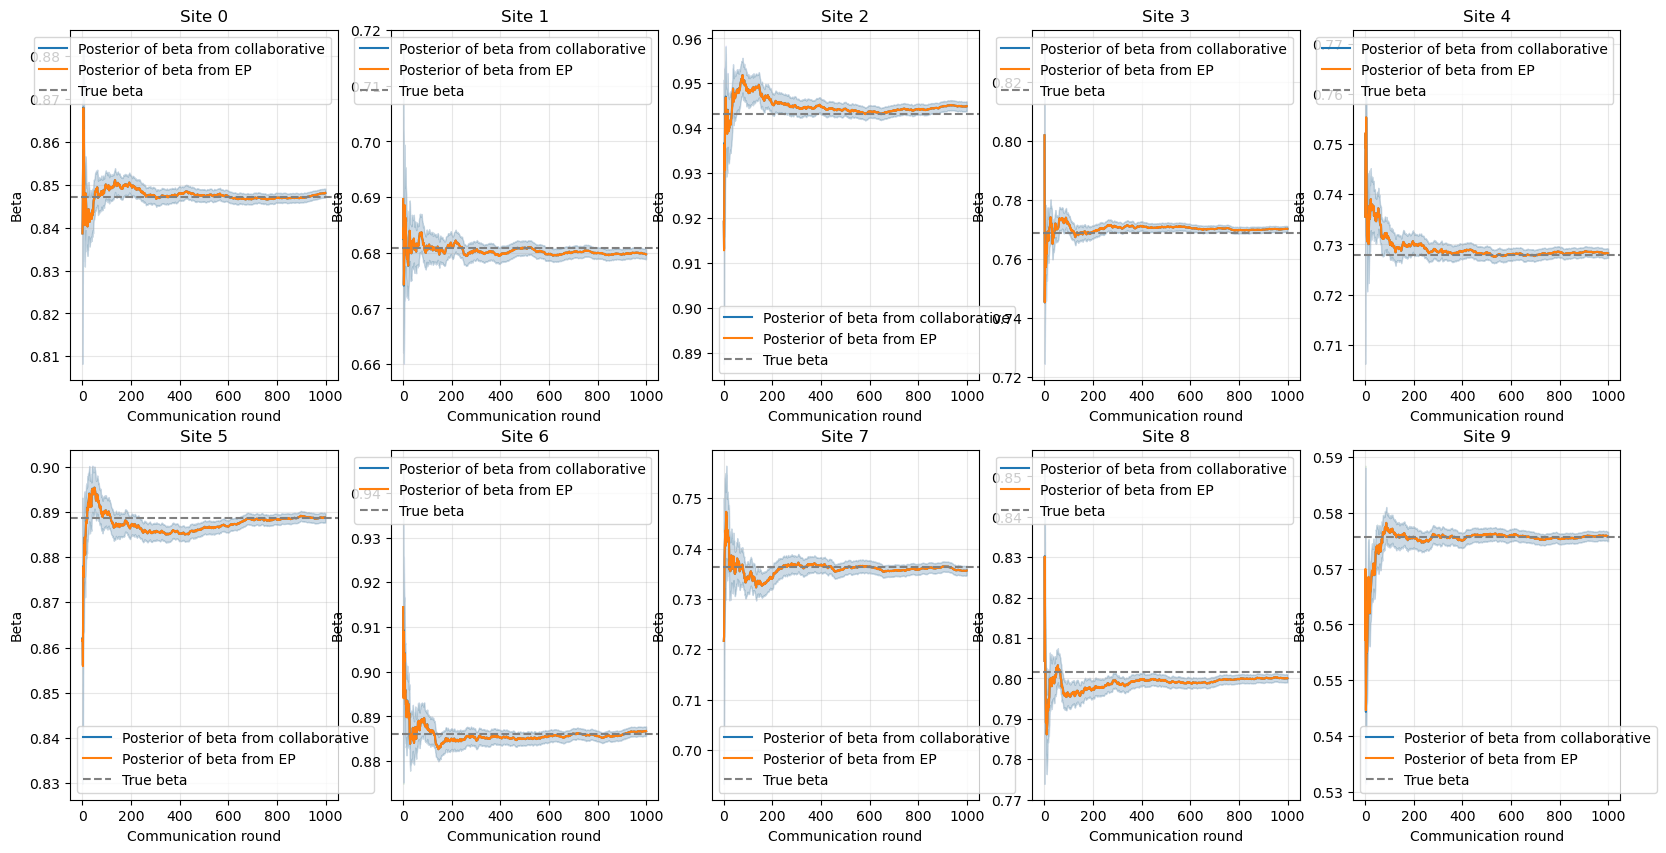

In [27]:
fig, ax = plt.subplots(2, 5, figsize=(20, 10))
t_list = np.arange(args['M'])
for i in range(args['N']):
    ax[i // 5, i % 5].plot(t_list, mu_mean[i, :], label='Posterior of beta from collaborative')
    ax[i // 5, i % 5].fill_between(t_list, mu_mean[i, :] - mu_std[i, :], mu_mean[i, :] + mu_std[i, :], color='blue', alpha=0.1)
    
    ax[i // 5, i % 5].plot(t_list, mu_mean_ep[i, :], label='Posterior of beta from EP')
    ax[i // 5, i % 5].fill_between(t_list, mu_mean_ep[i, :] - mu_std_ep[i, :], mu_mean_ep[i, :] + mu_std_ep[i, :], color='green', alpha=0.1)
    
    ax[i // 5, i % 5].axhline(true_mu[i], linestyle='--', color='grey', label='True beta')
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
    ax[i // 5, i % 5].set_title(f'Site {i}')
    ax[i // 5, i % 5].set_xlabel('Communication round')
    ax[i // 5, i % 5].set_ylabel('Beta')
    ax[i // 5, i % 5].legend()

In [ ]:
def run_sim(args, r, experiment="federated"):
    print(f'Simulation round {r+1}: running {experiment} experiment...')
    # Set placeholder for history
    hist_k_list = [[] for n in range(args['N'])]
    hist_lk_list = [[] for n in range(args['N'])]
    hist_cost_list = [[] for n in range(args['N'])]

    mu1_list = np.random.randn(args['N']) * args['sigma2'] + args['mu_true'] # Sample mu1's
    
    # Prior for (mu2, mu1_list)
    B0 = np.zeros((args['N']+1, 1))
    B0[0, 0] = args['mu3'] / args['sigma3']**2
    
    A0 = np.zeros((args['N']+1, args['N']+1))
    A0[0, 0] = args['N'] / args['sigma2']**2 + 1 / args['sigma3']**2
    
    for i in range(args['N']):
        A0[0, i+1] = -1 / args['sigma2']**2
        A0[i+1, 0] = -1 / args['sigma2']**2
        A0[i+1, i+1] = 1 / args['sigma2']**2

    # Calculate prior for mean and covariance
    mu0_mean = np.linalg.solve(A0, B0).flatten()        
    mu0_cov = np.linalg.inv(A0)
    mu0_std = np.sqrt(np.diag(mu0_cov))

    if experiment == 'federated_EP':
        Q_list = 1 / np.diag(mu0_cov[1:, 1:])
        r_list = np.multiply(Q_list,  mu0_mean[1:])

        r0 = args['mu3'] / args['sigma3']**2
        Q0 = 1 / args['sigma3']**2

        r0 += np.sum(r_list)
        Q0 += np.sum(Q_list)
        
    print(f"True mu are {[args['mu_true']] + list(mu1_list)}")
    mu0_mean_mat = np.zeros((args['N'], args['M']))
    mu0_std_mat = np.zeros((args['N'], args['M']))
    # Simulate
    for i in range(args['M']):
        print(f"--------Machine: {i+1}---------")
        # mu is vector of (mu2, mu1^(1), mu1^(2), ..., mu1^(N)) in R^{N+1}
        
        print(f"Prior for mean of vector mu is {mu0_mean}")
        print(f"Prior for std of vector mu is {mu0_std}")
        if experiment == 'federated_EP':
            print("***************")
            print(f"Prior for r is {r_list}")
            print(f"Prior for Q is {Q_list}")
            print("***************")
        
        for n in range(args['N']):
            # print(f"********Site {n+1}*********")
            mu1_mean = args['mu3'] if experiment == "OVI" else mu0_mean[n+1] # prior mean of mu1
            mu1_std = np.sqrt(args['sigma1']**2 + args['sigma2']**2 + args['sigma3']) if experiment == "OVI" else np.sqrt(mu0_std[n+1]**2 + args['sigma']**2) # prior std of mu1
            mu1 = mu1_list[n] # true mu1
            
            # Simulate beta true
            beta_true = np.random.randn(1) * args['sigma1'] + mu1
            
            # Simulate transitions
            lk_list = sample_transition(beta_true, args)
            discrete_lk_list, bins = discretize_states(lk_list, args)
    
            # Derive optimal policy pi
            if experiment in ("federated", "federated_EP", "isolated") or (experiment == "OVI" and n == 0):
                # print(mu1_mean, mu1_std)
                value, pi = value_iteration(mu1_mean, mu1_std, bins, args)
                # print("Finish value iteration")

            # plt.matshow(np.flip(np.transpose(pi), axis=0))
            # plt.show()

            # ------------------ Calculate cost ------------------------------------
            k, lk, cost = calc_cost(pi, lk_list, discrete_lk_list, args)
            hist_lk_list[n].append((k, lk))
            hist_cost_list[n].append(cost)
            print("Device %s, k: %s, lk: %.4f, cost: %.4f"%(n,k,lk,cost))

        # Update posterior
        if experiment == "federated":
            mu0_mean, _, mu0_std = update_posterior(hist_lk_list, args)
        elif experiment == "isolated":
            mu0_mean, mu0_std = update_isolated_posterior(hist_lk_list, args)
        elif experiment == 'federated_EP':
            r0, Q0, r_list_new, Q_list_new = update_EP_posterior(r_list, Q_list, r0, Q0, hist_lk_list, args)
            mu0_mean, mu0_std = device_posterior_update(r0, Q0, r_list_new, Q_list_new, hist_lk_list,args)

            # Update r_list and Q_list
            r_list_old = r_list; Q_list_old = Q_list
            r_list = r_list_new; Q_list = Q_list_new
            
        mu0_mean_mat[:, i] = mu0_mean[1:]
        mu0_std_mat[:, i] = mu0_std[1:]

    return hist_lk_list, hist_cost_list, mu0_mean_mat, mu0_std_mat, mu1_list